In [1]:
"""Actions for Better Ad Management
Action: Adjust the number of ads based on how long a person has been watching.

Reason: The data shows that watch_duration_minutes is a key factor in ad exposure; users watching shorter videos should see fewer ads to prevent them from leaving early.

Action: Standardize ad loads for different subscription types.

Reason: The model identifies that subscription_type (Free vs. Ad-supported) significantly changes how many ads are shown, and keeping this balanced is essential for a "Normal Ad Load".

Action: Use the predictive model to "round" ad counts to the nearest whole number before showing them.

Reason: The system generates a "Raw prediction" (like 2.99), which must be rounded to a "Rounded count" (3 ads) to make sense in a real-world viewing session."""

'Actions for Better Ad Management\nAction: Adjust the number of ads based on how long a person has been watching.\n\nReason: The data shows that watch_duration_minutes is a key factor in ad exposure; users watching shorter videos should see fewer ads to prevent them from leaving early.\n\nAction: Standardize ad loads for different subscription types.\n\nReason: The model identifies that subscription_type (Free vs. Ad-supported) significantly changes how many ads are shown, and keeping this balanced is essential for a "Normal Ad Load".\n\nAction: Use the predictive model to "round" ad counts to the nearest whole number before showing them.\n\nReason: The system generates a "Raw prediction" (like 2.99), which must be rounded to a "Rounded count" (3 ads) to make sense in a real-world viewing session.'

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

In [ ]:
#load data
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/NIQ_analytics/Media_analytics_synthetic_50k.csv')

print(f' Data loaded!')
print(f' Rows    : {df.shape[0]:,}')
print(f' Columns : {df.shape[1]}')
print(f' Columns : {df.columns.tolist()}')
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data loaded!
 Rows    : 50,000
 Columns : 17
 Columns : ['event_id', 'user_id', 'age_group', 'gender', 'device_type', 'os', 'content_type', 'content_genre', 'watch_duration_minutes', 'session_start_hour', 'ad_exposure_count', 'ad_skipped', 'subscription_type', 'network_type', 'buffering_events', 'rating_given', 'timestamp']


,event_id,user_id,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,subscription_type,network_type,buffering_events,rating_given,timestamp
0,1,1785,25-34,Female,Mobile,Android,News,Action,13.33,16,4,0,Ad-supported,4G,1,3.0,23-03-2025 01:39
1,2,1359,55+,Female,Laptop,Windows,News,Sports,11.84,9,2,0,Free,WiFi,0,3.0,24-06-2025 03:36
2,3,3214,45-54,Male,Mobile,iOS,News,Comedy,24.25,21,4,0,Free,4G,0,3.0,05-02-2025 23:36
3,4,17101,45-54,Female,Tablet,Windows,Movie,Comedy,31.93,8,1,0,Free,WiFi,1,4.0,15-03-2025 12:50
4,5,8184,45-54,Male,Laptop,Android,Kids,Drama,23.09,19,3,0,Ad-supported,4G,0,5.0,28-01-2025 09:59
5,6,9901,25-34,Other,Mobile,iOS,Kids,Thriller,26.85,20,2,1,Free,5G,1,4.0,24-03-2025 00:56
6,7,1894,18-24,Male,Laptop,Windows,Kids,Romance,26.64,8,2,0,Free,5G,0,1.0,31-01-2025 16:58
7,8,5517,25-34,Female,Tablet,Windows,Movie,Drama,26.70,7,1,0,Free,4G,1,4.0,04-01-2025 21:22
8,9,18775,18-24,Female,Laptop,Android,TV Show,Sports,11.60,21,1,0,Free,5G,0,3.0,27-02-2025 02:02
9,10,19387,55+,Female,Smart TV,macOS,News,Romance,21.02,21,3,0,Ad-supported,5G,0,4.0,09-03-2025 06:11


In [ ]:
#describe data
print('Data Types')
print(df.dtypes)
print('Description')
df.describe()

Data Types
event_id                    int64
user_id                     int64
age_group                  object
gender                     object
device_type                object
os                         object
content_type               object
content_genre              object
watch_duration_minutes    float64
session_start_hour          int64
ad_exposure_count           int64
ad_skipped                  int64
subscription_type          object
network_type               object
buffering_events            int64
rating_given              float64
timestamp                  object
dtype: object
Description


,event_id,user_id,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,buffering_events,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49053.000000
mean,25000.500000,9998.290000,29.963837,13.085220,2.069560,0.249840,0.504660,3.254256
std,14433.901067,5787.473491,29.796990,6.497775,1.640529,0.432925,0.710372,1.173998
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,12500.750000,4995.000000,8.580000,7.000000,1.000000,0.000000,0.000000,3.000000
50%,25000.500000,10026.000000,20.930000,13.000000,2.000000,0.000000,0.000000,3.000000
75%,37500.250000,15006.000000,41.590000,19.000000,3.000000,0.000000,1.000000,4.000000
max,50000.000000,19999.000000,327.430000,23.000000,13.000000,1.000000,5.000000,5.000000


In [ ]:
#data qulaity checks

In [ ]:
#check missing values
print('Missing values\n')
missing=df.isnull().sum()
missing_pct=(df.isnull().sum()/len(df)*100).round(2)
missing_df=pd.DataFrame({'Column':missing.index,'Missing Count': missing.values,'Missing %':missing_pct.values,'Actin needed': ['YES — fill with median' if v > 0 else 'None' for v in missing.values] })
print(missing_df.to_string(index=False))

print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
print(f'Most are in rating_given — we will fill with the median rating.')


Missing values

                Column  Missing Count  Missing %           Actin needed
              event_id              0       0.00                   None
               user_id              0       0.00                   None
             age_group              0       0.00                   None
                gender              0       0.00                   None
           device_type              0       0.00                   None
                    os              0       0.00                   None
          content_type              0       0.00                   None
         content_genre              0       0.00                   None
watch_duration_minutes              0       0.00                   None
    session_start_hour              0       0.00                   None
     ad_exposure_count              0       0.00                   None
            ad_skipped              0       0.00                   None
     subscription_type              0       0.00

In [ ]:
#Duplicate row check

dup=df.duplicated().sum()
print(f'Duplicate rows: {dup}')

Duplicate rows: 0


  watch_duration_minutes        : 2,406 outliers  (acceptable range: -40.9 to 91.1)
  ad_exposure_count             : 627 outliers  (acceptable range: -2.0 to 6.0)
  buffering_events              : 737 outliers  (acceptable range: -1.5 to 2.5)
We keep them — extreme sessions are valid data, not errors.


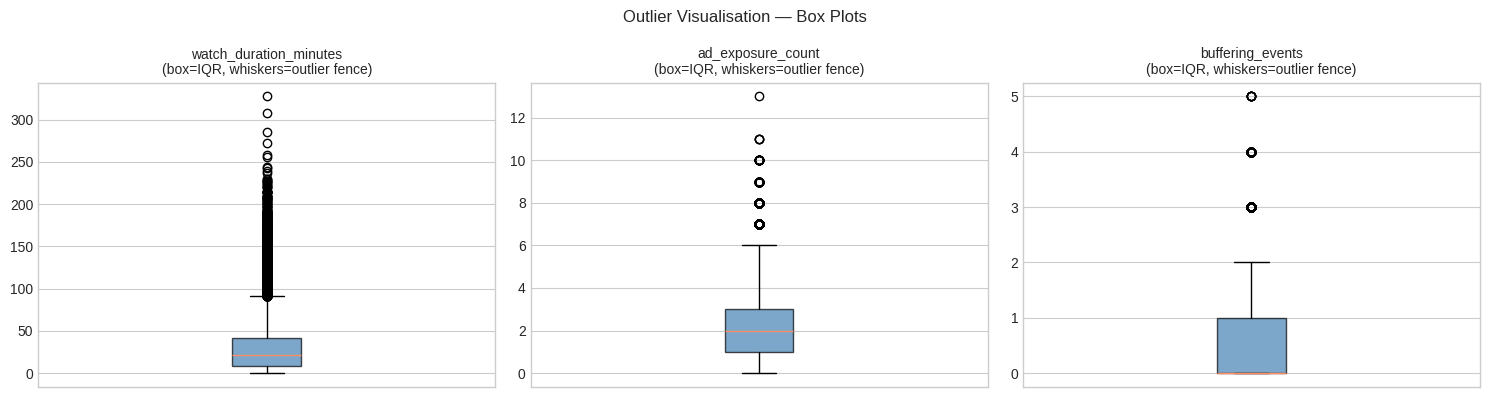

In [ ]:
#Outlier Detection Using IQR

numeric_cols = ['watch_duration_minutes', 'ad_exposure_count', 'buffering_events']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:30s}: {outliers:,} outliers  (acceptable range: {lower:.1f} to {upper:.1f})')


print('We keep them — extreme sessions are valid data, not errors.')

# Box plots to visualise outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(f'{col}\n(box=IQR, whiskers=outlier fence)', fontsize=10)
    ax.set_xticks([])
plt.suptitle('Outlier Visualisation — Box Plots', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#Cardinality Check
print('=== CARDINALITY CHECK (unique values per column) ===\n')

cardinality = []
for col in df.columns:
    n_unique = df[col].nunique()
    pct = n_unique / len(df) * 100
    dtype = str(df[col].dtype)

    if n_unique <= 2:
        flag = ' Binary'
    elif n_unique <= 10:
        flag = ' Low — safe for encoding'
    elif n_unique <= 50:
        flag = ' Medium — encode with care'
    elif n_unique == len(df):
        flag = ' Unique ID — DROP'
    else:
        flag = ' High — likely an ID column'

    cardinality.append({'Column': col, 'Unique Values': n_unique, '% of Rows': round(pct, 2),
                        'Data Type': dtype, 'Assessment': flag})

card_df = pd.DataFrame(cardinality)
print(card_df.to_string(index=False))

print('\n Columns we will DROP (IDs, not predictive):')
print('   - event_id  - just a row number')
print('   - user_id   - too many unique values (17k+); would memorise, not generalise')
print('   - timestamp - we extract useful signals (hour, weekday) from it instead')

=== CARDINALITY CHECK (unique values per column) ===

                Column  Unique Values  % of Rows Data Type                  Assessment
              event_id          50000     100.00     int64            Unique ID — DROP
               user_id          18345      36.69     int64  High — likely an ID column
             age_group              6       0.01    object     Low — safe for encoding
                gender              3       0.01    object     Low — safe for encoding
           device_type              5       0.01    object     Low — safe for encoding
                    os              5       0.01    object     Low — safe for encoding
          content_type              5       0.01    object     Low — safe for encoding
         content_genre              7       0.01    object     Low — safe for encoding
watch_duration_minutes          10185      20.37   float64  High — likely an ID column
    session_start_hour             24       0.05     int64   Medium — encode

In [ ]:
#Show all unique values
cat_col=['age_group','gender','device_type','os','content_type',
            'content_genre','subscription_type','network_type']

for col in cat_col:
    vals = sorted(df[col].dropna().unique())
    print(f'  {col:22s} ({len(vals)} values): {vals}')

  age_group              (6 values): ['18-24', '25-34', '35-44', '45-54', '55+', 'Other']
  gender                 (3 values): ['Female', 'Male', 'Other']
  device_type            (5 values): ['Laptop', 'Mobile', 'Set-top Box', 'Smart TV', 'Tablet']
  os                     (5 values): ['Android', 'Linux', 'Windows', 'iOS', 'macOS']
  content_type           (5 values): ['Kids', 'Live Sports', 'Movie', 'News', 'TV Show']
  content_genre          (7 values): ['Action', 'Comedy', 'Documentary', 'Drama', 'Romance', 'Sports', 'Thriller']
  subscription_type      (3 values): ['Ad-supported', 'Free', 'Premium']
  network_type           (4 values): ['4G', '5G', 'Broadband', 'WiFi']


In [ ]:
# ── Data Quality Summary Dashboard ──
print('=' * 60)
print('   DATA QUALITY SUMMARY REPORT')
print('=' * 60)

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness = (1 - missing_cells / total_cells) * 100

print(f'''
Dataset Size
   Rows    : {df.shape[0]:,}
   Columns : {df.shape[1]}
   Total cells : {total_cells:,}

Completeness
   Missing cells : {missing_cells:,} ({100-completeness:.2f}% of all data)
   Completeness  : {completeness:.2f}%
   Affected cols : rating_given only (~{df['rating_given'].isnull().sum()/len(df)*100:.1f}% missing)

Uniqueness
   Duplicate rows : {df.duplicated().sum()}
   Unique users   : {df['user_id'].nunique():,}
   Unique sessions: {df['event_id'].nunique():,}

 Validity (no impossible values found)
   Watch duration : {df['watch_duration_minutes'].min():.1f} – {df['watch_duration_minutes'].max():.1f} min
   Ad count       : {df['ad_exposure_count'].min()} – {df['ad_exposure_count'].max()} ads
   Session hour   : {df['session_start_hour'].min()} – {df['session_start_hour'].max()}
   Rating range   : {df['rating_given'].min():.0f} – {df['rating_given'].max():.0f} stars

 Target Variable (ad_exposure_count)
   Mean   : {df['ad_exposure_count'].mean():.2f} ads per session
   Median : {df['ad_exposure_count'].median():.0f} ads
   Std    : {df['ad_exposure_count'].std():.2f}
   Most common count: {df['ad_exposure_count'].mode()[0]} ads

OVERALL QUALITY: GOOD — Data is ready for modelling
   Only action needed: fill missing rating_given with median
''')
print('=' * 60)

   DATA QUALITY SUMMARY REPORT

Dataset Size
   Rows    : 50,000
   Columns : 17
   Total cells : 850,000

Completeness
   Missing cells : 947 (0.11% of all data)
   Completeness  : 99.89%
   Affected cols : rating_given only (~1.9% missing)

Uniqueness
   Duplicate rows : 0
   Unique users   : 18,345
   Unique sessions: 50,000

 Validity (no impossible values found)
   Watch duration : 0.0 – 327.4 min
   Ad count       : 0 – 13 ads
   Session hour   : 0 – 23
   Rating range   : 1 – 5 stars

 Target Variable (ad_exposure_count)
   Mean   : 2.07 ads per session
   Median : 2 ads
   Std    : 1.64
   Most common count: 1 ads

OVERALL QUALITY: GOOD — Data is ready for modelling
   Only action needed: fill missing rating_given with median



In [ ]:
#EDA

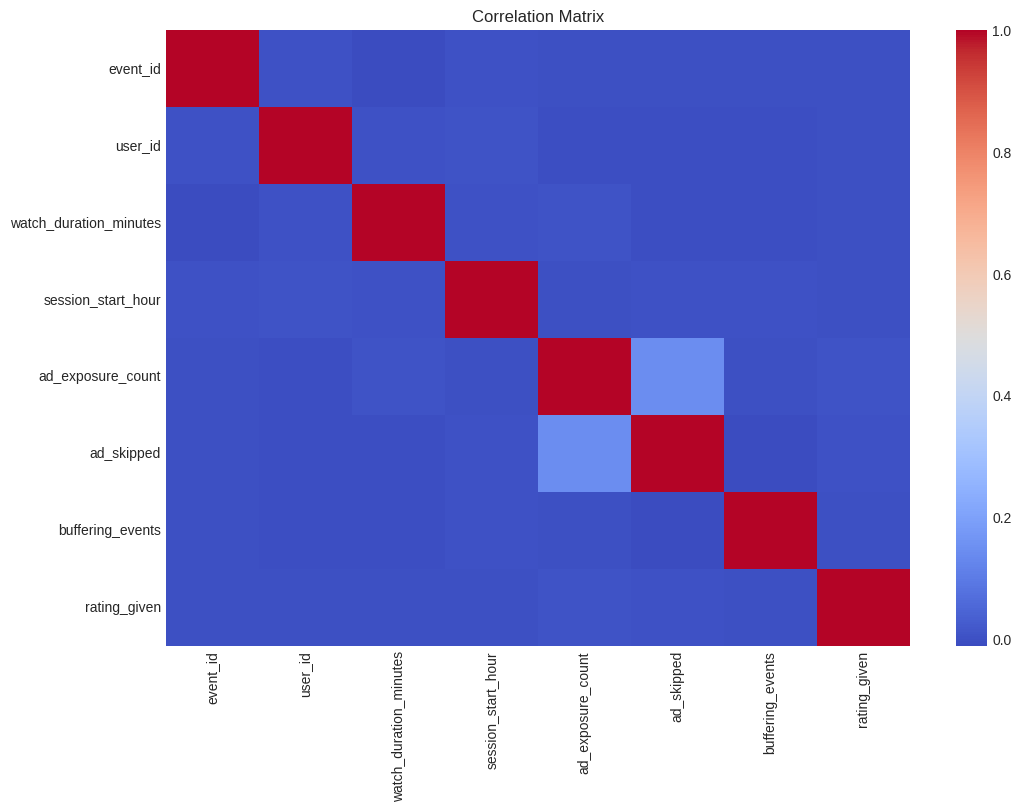

In [ ]:
#correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


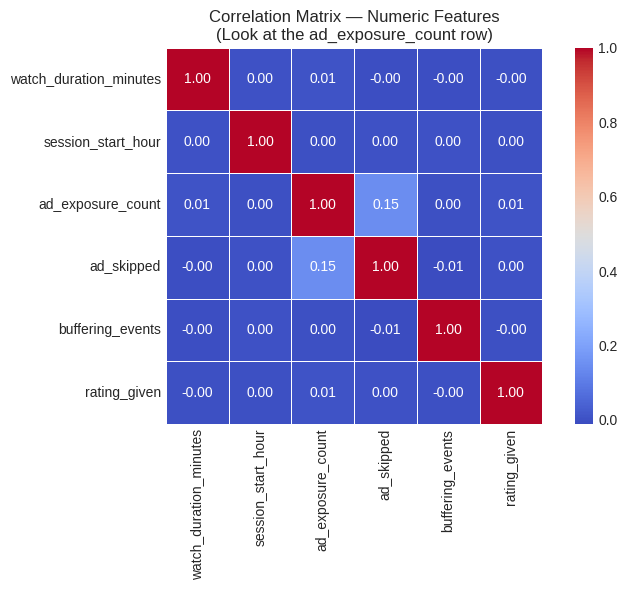

 watch_duration_minutes has POSITIVE correlation: longer sessions = more ads
 ad_skipped has NEGATIVE correlation: skip-prone users see fewer total ads
 buffering/rating have WEAK correlation: indirect effect only


In [ ]:
numeric_cols = ['watch_duration_minutes','session_start_hour','ad_exposure_count',
                'ad_skipped','buffering_events','rating_given']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features\n(Look at the ad_exposure_count row)', fontsize=12)
plt.tight_layout()
plt.show()
print(' watch_duration_minutes has POSITIVE correlation: longer sessions = more ads')
print(' ad_skipped has NEGATIVE correlation: skip-prone users see fewer total ads')
print(' buffering/rating have WEAK correlation: indirect effect only')

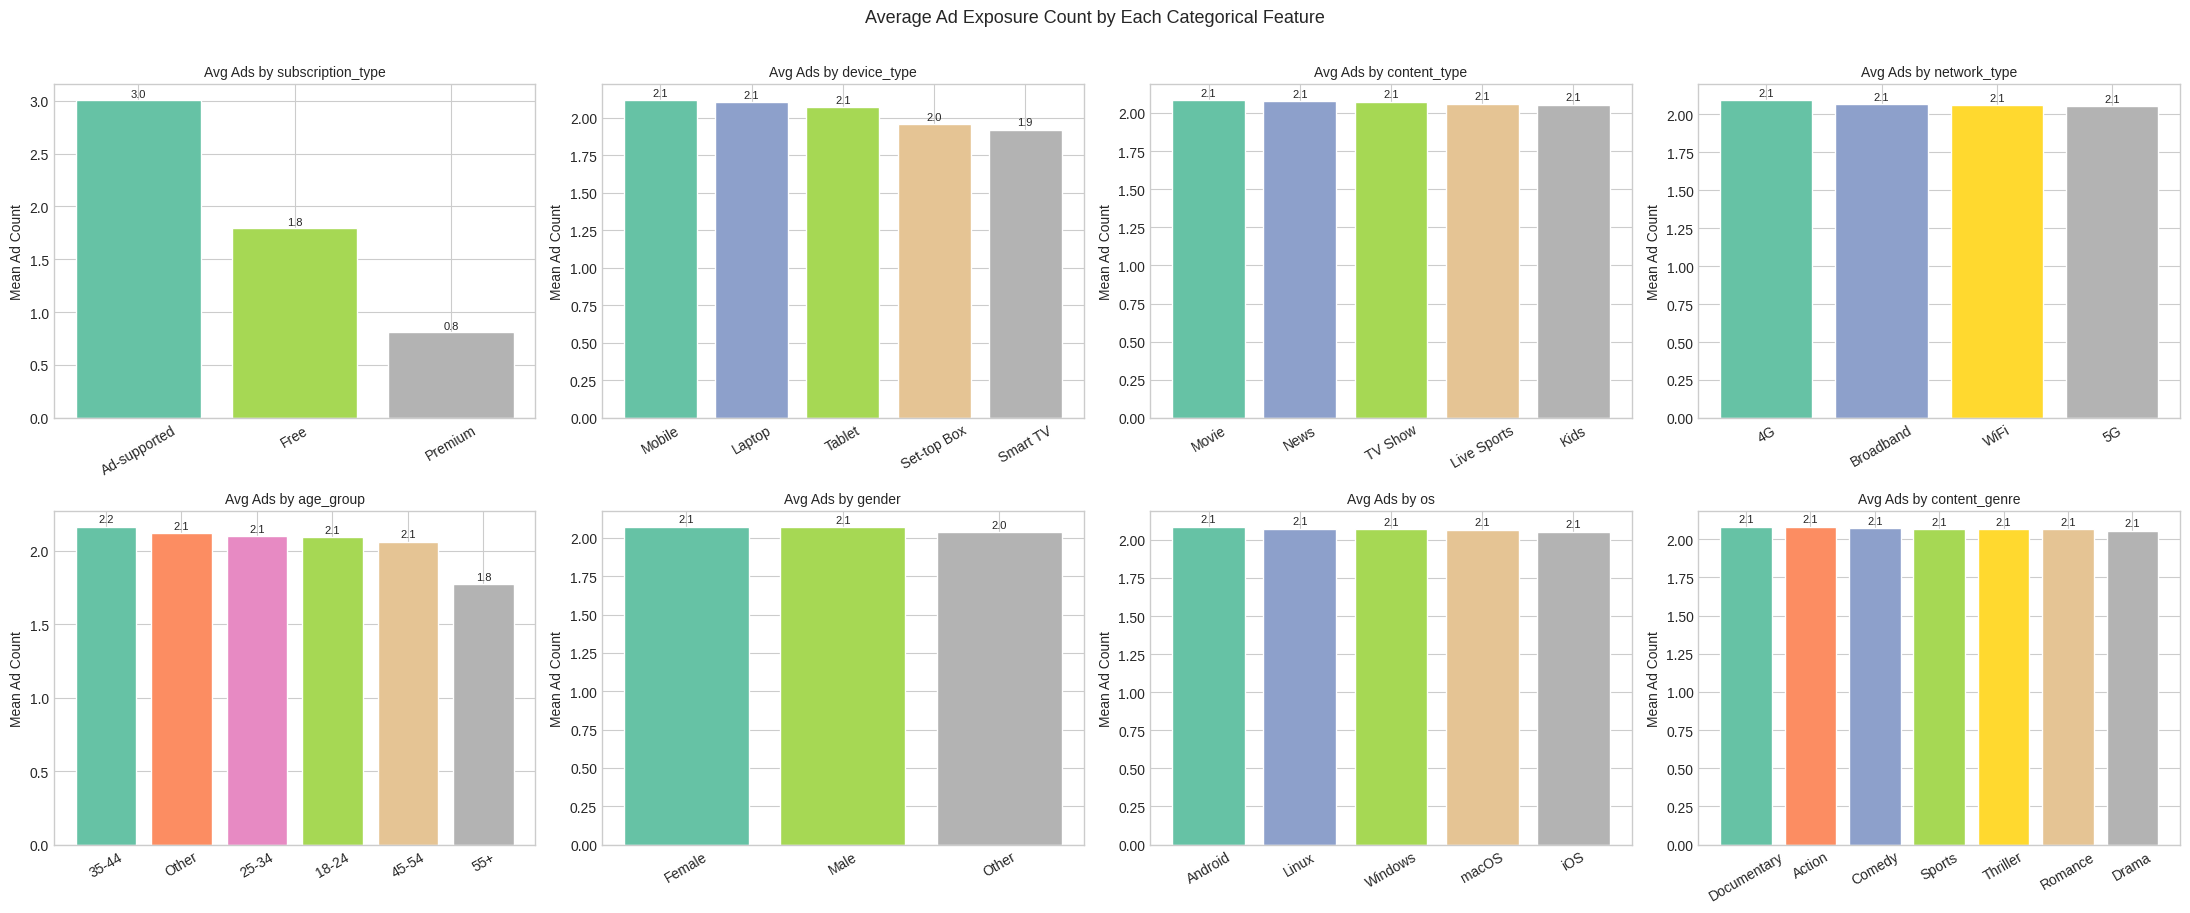

 Subscription type is the DOMINANT driver:
 Free & Premium users: ~0 ads | Ad-supported users: ~3-4 ads
 Device type, content type, and network also affect ad count


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))

cat_cols_plot = ['subscription_type','device_type','content_type','network_type',
                 'age_group','gender','os','content_genre']

for ax, col in zip(axes.flat, cat_cols_plot):
    means = df.groupby(col)['ad_exposure_count'].mean().sort_values(ascending=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(means)))
    ax.bar(means.index, means.values, color=colors, edgecolor='white')
    ax.set_title(f'Avg Ads by {col}', fontsize=10)
    ax.set_ylabel('Mean Ad Count')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.03, f'{v:.1f}', ha='center', fontsize=8)

plt.suptitle('Average Ad Exposure Count by Each Categorical Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


print(' Subscription type is the DOMINANT driver:')
print(' Free & Premium users: ~0 ads | Ad-supported users: ~3-4 ads')
print(' Device type, content type, and network also affect ad count')

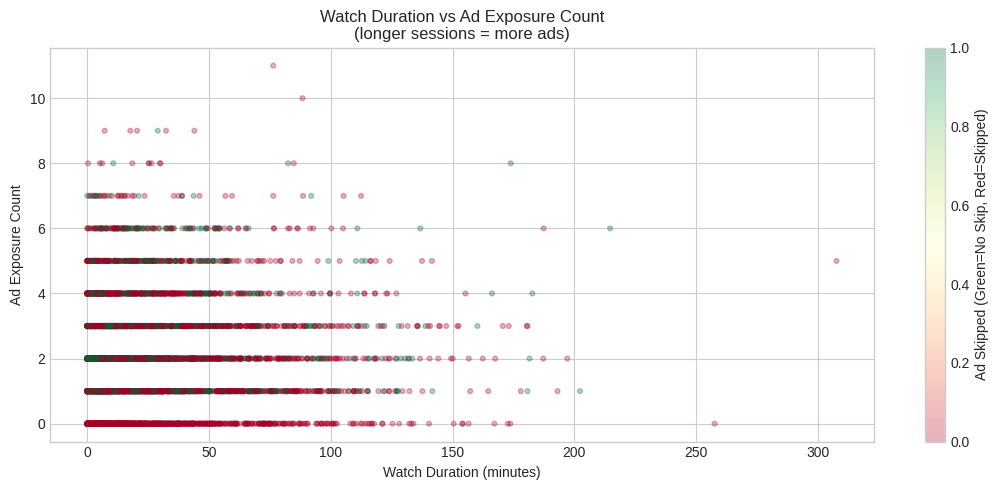

In [ ]:
#watch Duration vs ad count
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(11, 5))
sc = plt.scatter(sample['watch_duration_minutes'], sample['ad_exposure_count'],
                 alpha=0.3, c=sample['ad_skipped'], cmap='RdYlGn', s=12)
plt.colorbar(sc, label='Ad Skipped (Green=No Skip, Red=Skipped)')
plt.xlabel('Watch Duration (minutes)')
plt.ylabel('Ad Exposure Count')
plt.title('Watch Duration vs Ad Exposure Count\n(longer sessions = more ads)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
#Feature Engineering
df_model = df.copy()

# ── Parse timestamp and extract time features ──
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'], dayfirst=True)
df_model['hour']          = df_model['timestamp'].dt.hour
df_model['day_of_week']   = df_model['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
df_model['month']         = df_model['timestamp'].dt.month
df_model['is_weekend']    = (df_model['day_of_week'] >= 5).astype(int)
df_model['is_prime_time'] = ((df_model['hour'] >= 18) & (df_model['hour'] <= 23)).astype(int)


# ── Handle missing ratings ──
# ~2% are missing. Fill with median = safe choice that doesn't skew the data.
median_rating = df_model['rating_given'].median()
df_model['rating_given'].fillna(median_rating, inplace=True)

print(' Feature engineering complete!')
print('\nNew time features created:')
for f in ['hour','day_of_week','month','is_weekend','is_prime_time']:
    print(f'  {f:25s}: min={df_model[f].min():.1f}, max={df_model[f].max():.1f}')

print(f'\nMissing ratings filled with median: {median_rating}')


 Feature engineering complete!

New time features created:
  hour                     : min=0.0, max=23.0
  day_of_week              : min=0.0, max=6.0
  month                    : min=1.0, max=6.0
  is_weekend               : min=0.0, max=1.0
  is_prime_time            : min=0.0, max=1.0

Missing ratings filled with median: 3.0


In [ ]:
#encoding
cat_features = ['age_group','gender','device_type','os',
                'content_type','content_genre','subscription_type','network_type']

le_dict = {}  # Saved encoders - needed to encode NEW user data for predictions later

print(' ENCODING CATEGORICAL COLUMNS \n')
for col in cat_features:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:22s} → {mapping}')

print('\n All text columns converted to numbers')

 ENCODING CATEGORICAL COLUMNS 

  age_group              → {'18-24': np.int64(0), '25-34': np.int64(1), '35-44': np.int64(2), '45-54': np.int64(3), '55+': np.int64(4), 'Other': np.int64(5)}
  gender                 → {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  device_type            → {'Laptop': np.int64(0), 'Mobile': np.int64(1), 'Set-top Box': np.int64(2), 'Smart TV': np.int64(3), 'Tablet': np.int64(4)}
  os                     → {'Android': np.int64(0), 'Linux': np.int64(1), 'Windows': np.int64(2), 'iOS': np.int64(3), 'macOS': np.int64(4)}
  content_type           → {'Kids': np.int64(0), 'Live Sports': np.int64(1), 'Movie': np.int64(2), 'News': np.int64(3), 'TV Show': np.int64(4)}
  content_genre          → {'Action': np.int64(0), 'Comedy': np.int64(1), 'Documentary': np.int64(2), 'Drama': np.int64(3), 'Romance': np.int64(4), 'Sports': np.int64(5), 'Thriller': np.int64(6)}
  subscription_type      → {'Ad-supported': np.int64(0), 'Free': np.int64(1), 'Premium

In [ ]:
FEATURES = [
    # Encoded text columns (now numbers)
    'age_group_enc', 'gender_enc', 'device_type_enc', 'os_enc',
    'content_type_enc', 'content_genre_enc', 'subscription_type_enc', 'network_type_enc',
    # Original numeric columns
    'watch_duration_minutes', 'session_start_hour',
    'buffering_events', 'rating_given',
    # Engineered time features
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_prime_time',
]

TARGET = 'ad_exposure_count'

# Columns deliberately DROPPED and why:
print('=== COLUMNS DROPPED AND WHY ===')
print('  event_id - Just a row counter, zero predictive signal')
print('  user_id  - 17,000+ unique values — too high cardinality')
print('  timestamp - Extracted into hour, day, month, is_weekend, is_prime_time')

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'\nFeature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'   Target range: {y.min()} – {y.max()} ads')

=== COLUMNS DROPPED AND WHY ===
  event_id - Just a row counter, zero predictive signal
  user_id  - 17,000+ unique values — too high cardinality
  timestamp - Extracted into hour, day, month, is_weekend, is_prime_time

Feature matrix: 50,000 rows × 17 features
   Target range: 0 – 13 ads


In [ ]:
#split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42   # Fixed seed = same split every time you run
)

print(f'Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTarget distribution check:')
print(f'  Train mean: {y_train.mean():.3f} | Test mean: {y_test.mean():.3f}  ← should be close')
print('Good split — target distribution is similar in both sets')

Training set : 40,000 rows (80%)
Test set     : 10,000 rows (20%)

Target distribution check:
  Train mean: 2.069 | Test mean: 2.070  ← should be close
Good split — target distribution is similar in both sets


In [ ]:
# ── Define 3 Models — simplest to most powerful ──
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}


naive_pred = [y_train.mean()] * len(y_test)
naive_mae  = mean_absolute_error(y_test, naive_pred)
print(f'Naive baseline (always predict mean={y_train.mean():.2f} ads): MAE = {naive_mae:.4f}')
print(f'Any model with MAE < {naive_mae:.4f} is better than guessing\n')

# ── Metrics Explained ──
# MAE  = avg prediction error in number of ads   (lower is better)
# RMSE = like MAE but penalises big errors more   (lower is better)
# R²   = % of variance explained                  (higher is better; max=1.0)

results = []
print(f'{"Model":<22} {"MAE":>8} {"RMSE":>8} {"R2":>8}   vs Baseline')
print('-' * 72)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)
    pct  = (naive_mae - mae) / naive_mae * 100
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'preds': preds, 'model_obj': model})
    print(f'{name:<22} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}   +{pct:.1f}% better than baseline')

results_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['preds','model_obj']} for r in results])
best_name  = results_df.loc[results_df['MAE'].idxmin(), 'Model']
best_model = next(r['model_obj'] for r in results if r['Model'] == best_name)

print(f'\n Best model: {best_name}')

Naive baseline (always predict mean=2.07 ads): MAE = 1.2942
Any model with MAE < 1.2942 is better than guessing

Model                       MAE     RMSE       R2   vs Baseline
------------------------------------------------------------------------
Linear Regression        1.1209   1.4436   0.2397   +13.4% better than baseline
Random Forest            1.1474   1.4650   0.2170   +11.3% better than baseline

 Best model: Linear Regression


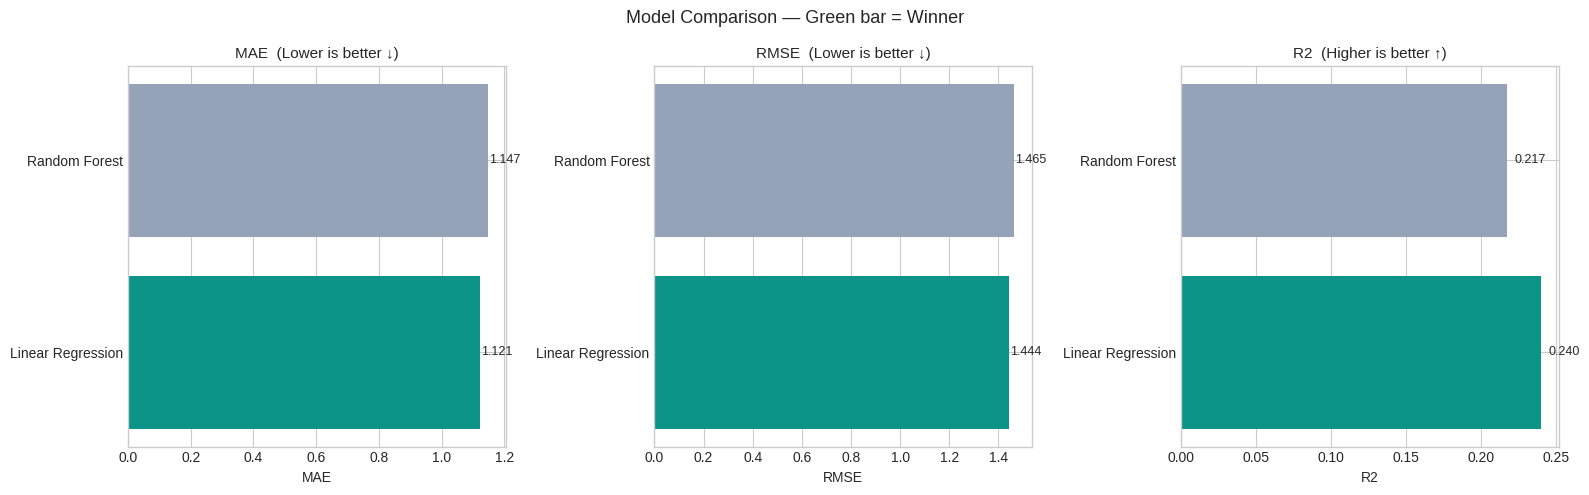

Best model: Linear Regression — used for all remaining steps


In [ ]:
# Model Comparison Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, ascending, label in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    [True, True, False],
    ['Lower is better ↓', 'Lower is better ↓', 'Higher is better ↑']
):
    sorted_df = results_df.sort_values(metric, ascending=ascending)
    colors = ['#0D9488' if i == 0 else '#94A3B8' for i in range(len(sorted_df))]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_title(f'{metric}  ({label})', fontsize=11)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Green bar = Winner', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Best model: {best_name} — used for all remaining steps')


In [ ]:
y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)
naive_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
improvement = (naive_mae - mae) / naive_mae * 100

print('=' * 58)
print(f'   {best_name.upper()} — FINAL TEST SET RESULTS')
print('=' * 58)
print(f'  Naive baseline MAE : {naive_mae:.4f}  (always predict mean={y_train.mean():.2f})')
print(f'  Our model MAE      : {mae:.4f}  → {improvement:.1f}% better than baseline')
print(f'  RMSE               : {rmse:.4f}')
print(f'  R²                 : {r2:.4f}  → explains {r2*100:.1f}% of ad count variance')
print('=' * 58)
print(f'\nBusiness interpretation:')
print(f'   Predictions are within ~{mae:.1f} ad of truth on average.')
print(f'   {improvement:.1f}% more accurate than just guessing the dataset mean.')


   LINEAR REGRESSION — FINAL TEST SET RESULTS
  Naive baseline MAE : 1.2942  (always predict mean=2.07)
  Our model MAE      : 1.1209  → 13.4% better than baseline
  RMSE               : 1.4436
  R²                 : 0.2397  → explains 24.0% of ad count variance

Business interpretation:
   Predictions are within ~1.1 ad of truth on average.
   13.4% more accurate than just guessing the dataset mean.


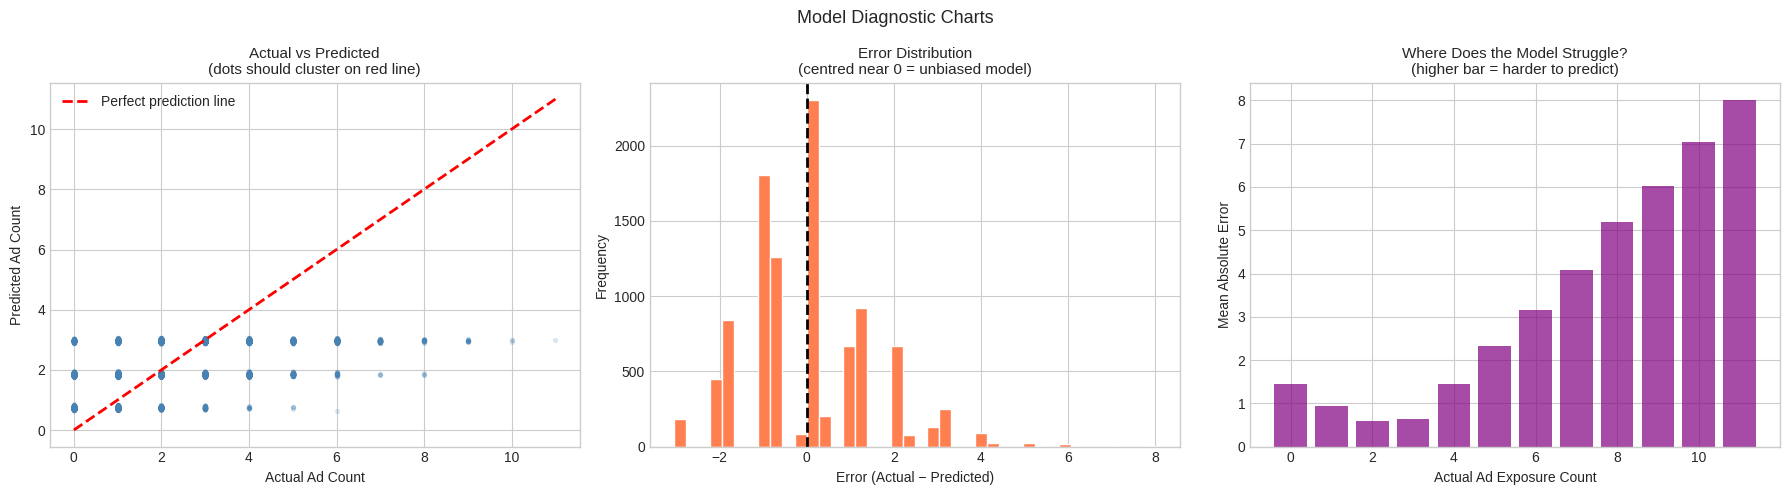

In [ ]:
# ── Diagnostic Charts — 3 ways to see how good our model is ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Actual vs Predicted
# Perfect model = all dots on the red diagonal line
axes[0].scatter(y_test, y_pred, alpha=0.15, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Ad Count')
axes[0].set_ylabel('Predicted Ad Count')
axes[0].set_title('Actual vs Predicted\n(dots should cluster on red line)', fontsize=11)
axes[0].legend()

# Chart 2: Residuals (errors)
# Should be bell-shaped and centred at 0
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Error (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution\n(centred near 0 = unbiased model)', fontsize=11)

# Chart 3: Error by ad count value

error_df = pd.DataFrame({'actual': y_test.values, 'abs_error': np.abs(residuals)})
error_means = error_df.groupby('actual')['abs_error'].mean()
axes[2].bar(error_means.index, error_means.values, color='purple', alpha=0.7)
axes[2].set_xlabel('Actual Ad Exposure Count')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title('Where Does the Model Struggle?\n(higher bar = harder to predict)', fontsize=11)

plt.suptitle('Model Diagnostic Charts', fontsize=13)
plt.tight_layout()
plt.show()

Running 5-fold cross-validation...
(Trains 5 separate models, takes 2–3 minutes)

=== 5-Fold Cross-Validation Results ===
  Fold 1: MAE = 1.1083
  Fold 2: MAE = 1.1090
  Fold 3: MAE = 1.0951
  Fold 4: MAE = 1.1125
  Fold 5: MAE = 1.1166
  ────────────────────────────
  Mean MAE : 1.1083
  Std  MAE : 0.0072  ← should be < 0.05 for stability

  Model is: STABLE 


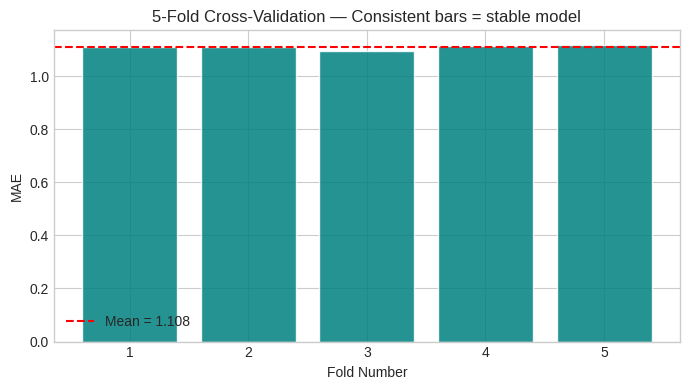

In [ ]:
print('Running 5-fold cross-validation...')
print('(Trains 5 separate models, takes 2–3 minutes)')

cv_scores = cross_val_score(
    best_model, X, y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
cv_mae = -cv_scores

print('\n=== 5-Fold Cross-Validation Results ===')
for i, mae_val in enumerate(cv_mae, 1):
    print(f'  Fold {i}: MAE = {mae_val:.4f}')
print(f'  {"─"*28}')
print(f'  Mean MAE : {cv_mae.mean():.4f}')
print(f'  Std  MAE : {cv_mae.std():.4f}  ← should be < 0.05 for stability')

stability = 'STABLE ' if cv_mae.std() < 0.05 else 'VARIABLE '
print(f'\n  Model is: {stability}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_mae, color='teal', edgecolor='white', alpha=0.85)
plt.axhline(cv_mae.mean(), color='red', linestyle='--', label=f'Mean = {cv_mae.mean():.3f}')
plt.xlabel('Fold Number')
plt.ylabel('MAE')
plt.title('5-Fold Cross-Validation — Consistent bars = stable model')
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#SHAP

In [ ]:
print('Computing SHAP values (may take 1-2 minutes)...')

X_sample = X_test.sample(2000, random_state=42)
explainer   = shap.Explainer(best_model, X_train.sample(1000, random_state=42))
shap_values = explainer(X_sample)

print('SHAP values computed for 2,000 test users')

Computing SHAP values (may take 1-2 minutes)...
SHAP values computed for 2,000 test users


SHAP Summary Plot — Tells us both importance AND direction of each feature


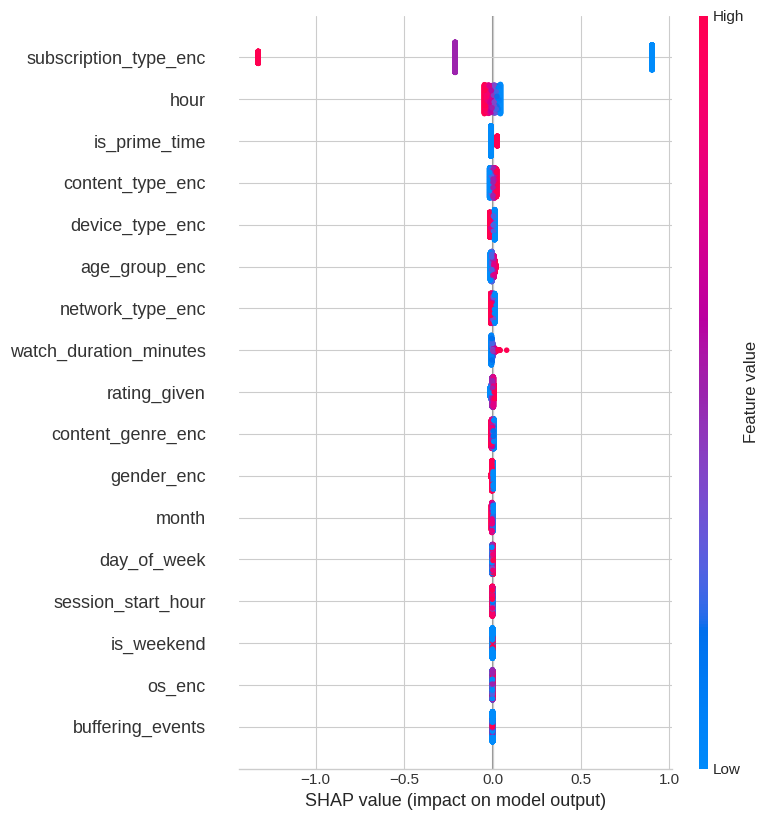

In [ ]:
print('SHAP Summary Plot — Tells us both importance AND direction of each feature')
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=True)
# Each row = one feature. Each dot = one user.
# Red = high feature value, Blue = low feature value
# Dots to the RIGHT = pushed prediction higher (more ads)
# Dots to the LEFT  = pushed prediction lower (fewer ads)

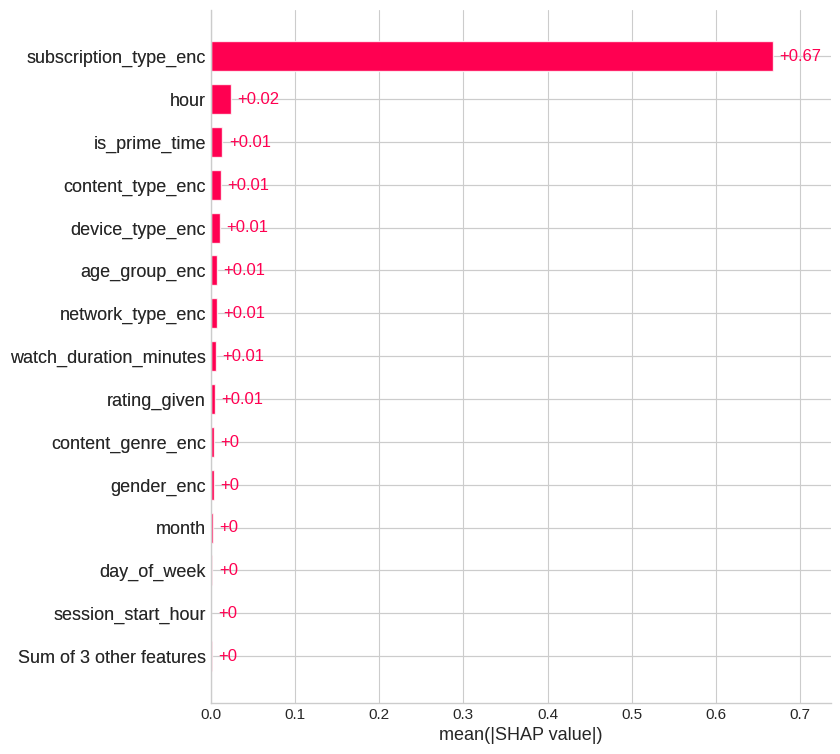

In [ ]:
shap.plots.bar(shap_values, max_display=15, show=True)

User #0 — Actual ads: 3 | Model predicted: 1.83
Waterfall chart below shows why:


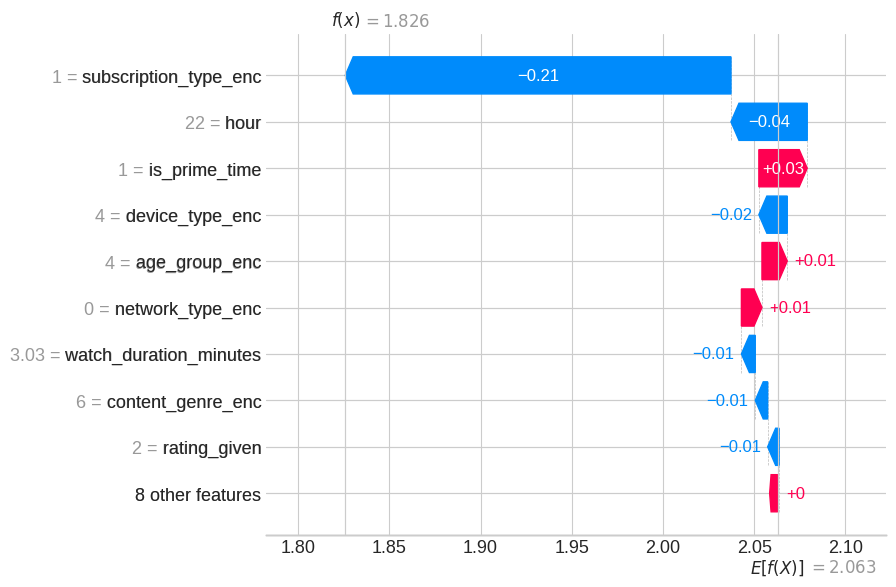

In [ ]:
sample_idx = 0
actual_val = y_test.values[X_sample.index.get_loc(X_sample.index[sample_idx])]
pred_val   = best_model.predict(X_sample.iloc[[sample_idx]])[0]

print(f'User #{sample_idx} — Actual ads: {actual_val} | Model predicted: {pred_val:.2f}')
print('Waterfall chart below shows why:')
shap.plots.waterfall(shap_values[sample_idx], show=True)

In [ ]:
def predict_ad_exposure(age_group, gender, device_type, os, content_type,
                         content_genre, subscription_type, network_type,
                         watch_duration, session_hour,
                         buffering_events, rating, is_weekend_flag, is_prime_time_flag):

    day_of_week = 5 if is_weekend_flag else 2   # Saturday or Wednesday
    month = 3                                    # Default to March

    new_user = pd.DataFrame([{
        'age_group_enc':          le_dict['age_group'].transform([age_group])[0],
        'gender_enc':             le_dict['gender'].transform([gender])[0],
        'device_type_enc':        le_dict['device_type'].transform([device_type])[0],
        'os_enc':                 le_dict['os'].transform([os])[0],
        'content_type_enc':       le_dict['content_type'].transform([content_type])[0],
        'content_genre_enc':      le_dict['content_genre'].transform([content_genre])[0],
        'subscription_type_enc':  le_dict['subscription_type'].transform([subscription_type])[0],
        'network_type_enc':       le_dict['network_type'].transform([network_type])[0],
        'watch_duration_minutes': watch_duration,
        'session_start_hour':     session_hour,
        'buffering_events':       buffering_events,
        'rating_given':           rating,
        'hour':                   session_hour,
        'day_of_week':            day_of_week,
        'month':                  month,
        'is_weekend':             is_weekend_flag,
        'is_prime_time':          is_prime_time_flag,
    }])

    raw_pred   = best_model.predict(new_user)[0]
    final_pred = max(0, round(raw_pred))
    return raw_pred, final_pred


# ── Test with 3 Example Users ──
test_users = [
    dict(age_group='25-34', gender='Male',   device_type='Mobile', os='Android',
         content_type='Movie', content_genre='Action', subscription_type='Ad-supported',
         network_type='4G',   watch_duration=45.0, session_hour=20,
         buffering_events=0, rating=4.0,
         is_weekend_flag=1, is_prime_time_flag=1,
         label='Ad-supported | Mobile | 45 min | Prime Time'),

    dict(age_group='18-24', gender='Female', device_type='Laptop', os='Windows',
         content_type='News', content_genre='Sports', subscription_type='Free',
         network_type='WiFi', watch_duration=15.0, session_hour=10,
         buffering_events=0, rating=3.0,
         is_weekend_flag=0, is_prime_time_flag=0,
         label='Free user | Laptop | 15 min | Morning'),

    dict(age_group='45-54', gender='Male',   device_type='Smart TV', os='Android',
         content_type='Live Sports', content_genre='Sports', subscription_type='Ad-supported',
         network_type='WiFi', watch_duration=90.0, session_hour=19,
         buffering_events=2, rating=2.0,
         is_weekend_flag=1, is_prime_time_flag=1,
         label='Ad-supported | Smart TV | 90 min | Live Sports'),
]

print('=' * 70)
print('   AD EXPOSURE COUNT PREDICTIONS FOR EXAMPLE USERS')
print('=' * 70)

for u in test_users:
    label = u.pop('label')
    raw, pred = predict_ad_exposure(**u)
    print(f'\n User: {label}')
    print(f'   Raw prediction : {raw:.2f}')
    print(f'   Rounded count  : {pred} ads')
    if pred >= 4:
        print(f'     AD FATIGUE RISK — show Premium upgrade prompt')
    elif pred == 0:
        print(f'   FREE USER WITH ENGAGEMENT — warm upsell lead')
    else:
        print(f'    NORMAL AD LOAD — no action needed')

   AD EXPOSURE COUNT PREDICTIONS FOR EXAMPLE USERS

 User: Ad-supported | Mobile | 45 min | Prime Time
   Raw prediction : 2.99
   Rounded count  : 3 ads
    NORMAL AD LOAD — no action needed

 User: Free user | Laptop | 15 min | Morning
   Raw prediction : 1.84
   Rounded count  : 2 ads
    NORMAL AD LOAD — no action needed

 User: Ad-supported | Smart TV | 90 min | Live Sports
   Raw prediction : 2.95
   Rounded count  : 3 ads
    NORMAL AD LOAD — no action needed
